In [2]:
import watermark
pkg_versions = watermark.watermark(
    packages="requests,pandas,tqdm,geopandas")
print(pkg_versions)

requests : 2.32.5
pandas   : 1.5.3
tqdm     : 4.67.1
geopandas: 1.0.1



In [3]:
import pandas as pd
df = pd.read_excel("내외국인 총관광소비 데이터.xlsx",sheet_name="연도별_지자체별_총 관광소비액")

In [4]:
df

,기준년월,지자체,총 관광소비액,외국인,내국인
0,2021,강서구,528969620,934347,528035273
1,2021,금정구,270647834,1693937,268953897
2,2021,기장군,820390034,4619426,815770608
3,2021,남구,330117949,1425502,328692447
4,2021,동구,258278434,1394359,256884075
...,...,...,...,...,...
75,2025,수영구,474487202,24027391,450459811
76,2025,연제구,450384543,2933400,447451143
77,2025,영도구,109061017,10134805,98926212
78,2025,중구,520564054,101348786,419215268


In [5]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/home/DL/.local/share/fonts/KoPubWorld/KoPubWorld Dotum Medium.ttf"

# 현재 Python 프로세스에 폰트 등록
fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()
print(font_name)

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

KoPubWorldDotum


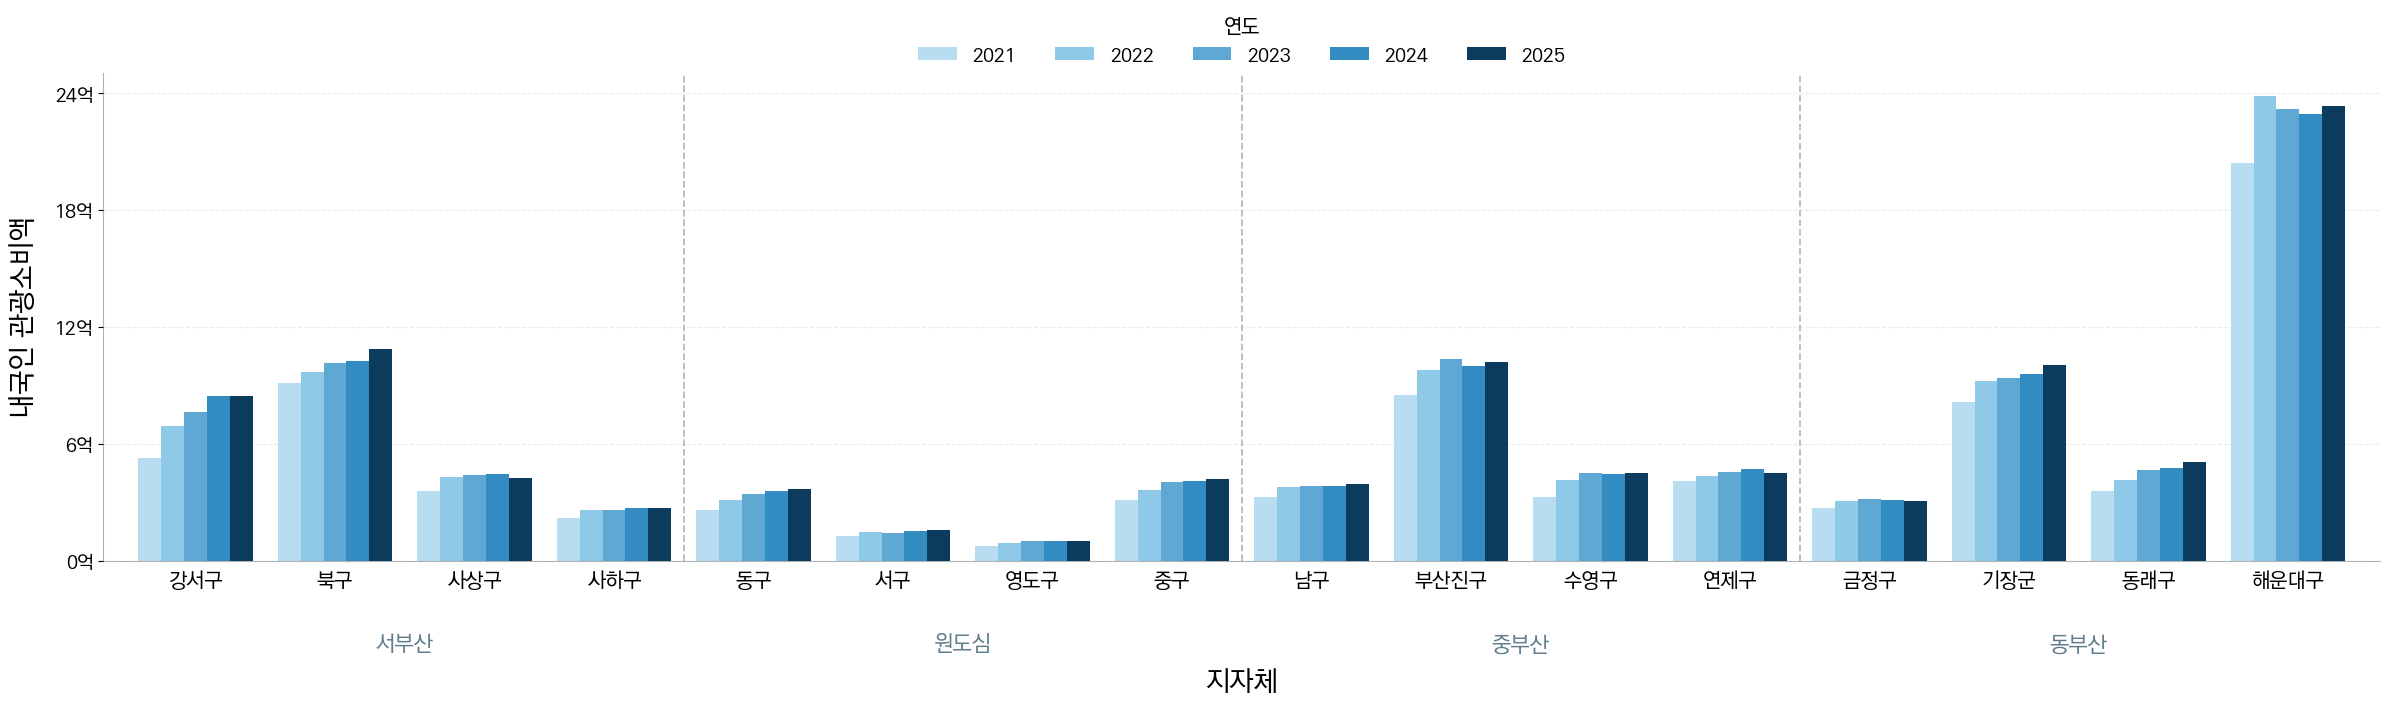

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator


# =========================================================
# 1. 데이터 복사
# =========================================================

df2 = df.copy()


# =========================================================
# 2. 부산 4개 권역 설정
# =========================================================

region_map = {
    # 원도심
    "중구": "원도심",
    "동구": "원도심",
    "서구": "원도심",
    "영도구": "원도심",

    # 중부산
    "남구": "중부산",
    "부산진구": "중부산",
    "수영구": "중부산",
    "연제구": "중부산",

    # 서부산
    "강서구": "서부산",
    "북구": "서부산",
    "사상구": "서부산",
    "사하구": "서부산",

    # 동부산
    "금정구": "동부산",
    "기장군": "동부산",
    "동래구": "동부산",
    "해운대구": "동부산",
}


# =========================================================
# 3. 권역 순서
# =========================================================

region_order = [
    "서부산",
    "원도심",
    "중부산",
    "동부산"
]


# =========================================================
# 4. 권역 추가
# =========================================================

df2["권역"] = df2["지자체"].map(region_map)

df2["권역"] = pd.Categorical(
    df2["권역"],
    categories=region_order,
    ordered=True
)


# =========================================================
# 5. 권역 → 지자체 가나다순 → 연도순
# =========================================================

plot_df = (
    df2
    .sort_values(
        ["권역", "지자체", "기준년월"],
        ascending=[True, True, True]
    )
    .copy()
)


# =========================================================
# 6. 피벗
# =========================================================

pivot_domestic = plot_df.pivot(
    index="지자체",
    columns="기준년월",
    values="내국인"
)


# =========================================================
# 7. 권역별 지자체 순서 생성
# =========================================================

gu_order = (
    plot_df[
        ["지자체", "권역"]
    ]
    .drop_duplicates()
    .sort_values(
        ["권역", "지자체"],
        ascending=[True, True]
    )
    ["지자체"]
    .tolist()
)


# =========================================================
# 8. 지자체 순서 + 연도 순서 적용
# =========================================================

pivot_domestic = (
    pivot_domestic
    .reindex(index=gu_order)
    .reindex(
        columns=[
            2021,
            2022,
            2023,
            2024,
            2025
        ]
    )
)


# =========================================================
# 9. 연도별 색상
# =========================================================

colors = [
    "#B8DDF0",
    "#8EC9E8",
    "#5FA8D3",
    "#328CC1",
    "#0B3C5D"
]


# =========================================================
# 10. 그래프
# =========================================================

fig, ax = plt.subplots(
    figsize=(24, 8)
)


pivot_domestic.plot(
    kind="bar",

    ax=ax,

    color=colors,

    width=0.82,

    edgecolor="none"
)


# =========================================================
# 11. 권역별 위치 정보
# =========================================================

region_positions = {}

for region in region_order:

    gu_in_region = (
        plot_df[
            plot_df["권역"] == region
        ]["지자체"]
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    positions = [
        gu_order.index(gu)
        for gu in gu_in_region
        if gu in gu_order
    ]

    if positions:

        region_positions[region] = {
            "start": min(positions),
            "end": max(positions)
        }


# =========================================================
# 12. 권역 사이 세로 점선
# =========================================================

for region in region_order:

    if region not in region_positions:
        continue

    start = region_positions[region]["start"]

    # 첫 번째 권역 앞에는 선 필요 없음
    if start > 0:

        ax.axvline(
            x=start - 0.5,

            color="#9E9E9E",

            linewidth=1.3,
            linestyle="--",

            alpha=0.7,

            zorder=0
        )


# =========================================================
# 13. 아래쪽 권역명
# =========================================================

for region in region_order:

    if region not in region_positions:
        continue

    start = region_positions[region]["start"]
    end = region_positions[region]["end"]

    center = (start + end) / 2

    ax.text(
        center,
        -0.15,

        region,

        transform=ax.get_xaxis_transform(),

        ha="center",
        va="top",

        fontsize=16,
        fontweight="bold",

        color="#607D8B"
    )


# =========================================================
# 14. X축
# =========================================================

ax.set_xlabel(
    "지자체",
    fontsize=20,
    fontweight="bold",
    labelpad=55
)


# =========================================================
# 15. Y축
# =========================================================

ax.set_ylabel(
    "내국인 관광소비액",
    fontsize=20,
    fontweight="bold",
    labelpad=12
)


# =========================================================
# 16. 틱
# =========================================================

ax.tick_params(
    axis="x",
    labelsize=15,
    rotation=0,
    pad=8,
    length=0
)

ax.tick_params(
    axis="y",
    labelsize=14
)


# =========================================================
# 17. Y축 억 단위
# =========================================================

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, _: f"{x / 100_000_000:,.0f}억"
    )
)


# =========================================================
# 18. Y축 틱 개수
# =========================================================

ax.yaxis.set_major_locator(
    MaxNLocator(
        nbins=5
    )
)


# =========================================================
# 19. 범례
# =========================================================

ax.legend(
    title="연도",

    fontsize=14,
    title_fontsize=15,

    ncol=5,

    frameon=False,

    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),

    columnspacing=2
)


# =========================================================
# 20. 가로 보조선
# =========================================================

ax.grid(
    axis="y",

    linestyle="--",
    linewidth=0.8,

    alpha=0.25
)

ax.set_axisbelow(True)


# =========================================================
# 21. 테두리
# 기존 스타일 그대로 유지
# =========================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_alpha(0.3)
ax.spines["bottom"].set_alpha(0.3)


# =========================================================
# 22. 레이아웃
#
# 아래 권역명 공간 확보
# =========================================================

plt.tight_layout(
    rect=[0, 0.08, 1, 1]
)


# =========================================================
# 23. 저장
# =========================================================

plt.savefig(
    "지자체별_연도별_내국인_관광소비액_4권역.png",

    dpi=300,
    bbox_inches="tight"
)


plt.show()

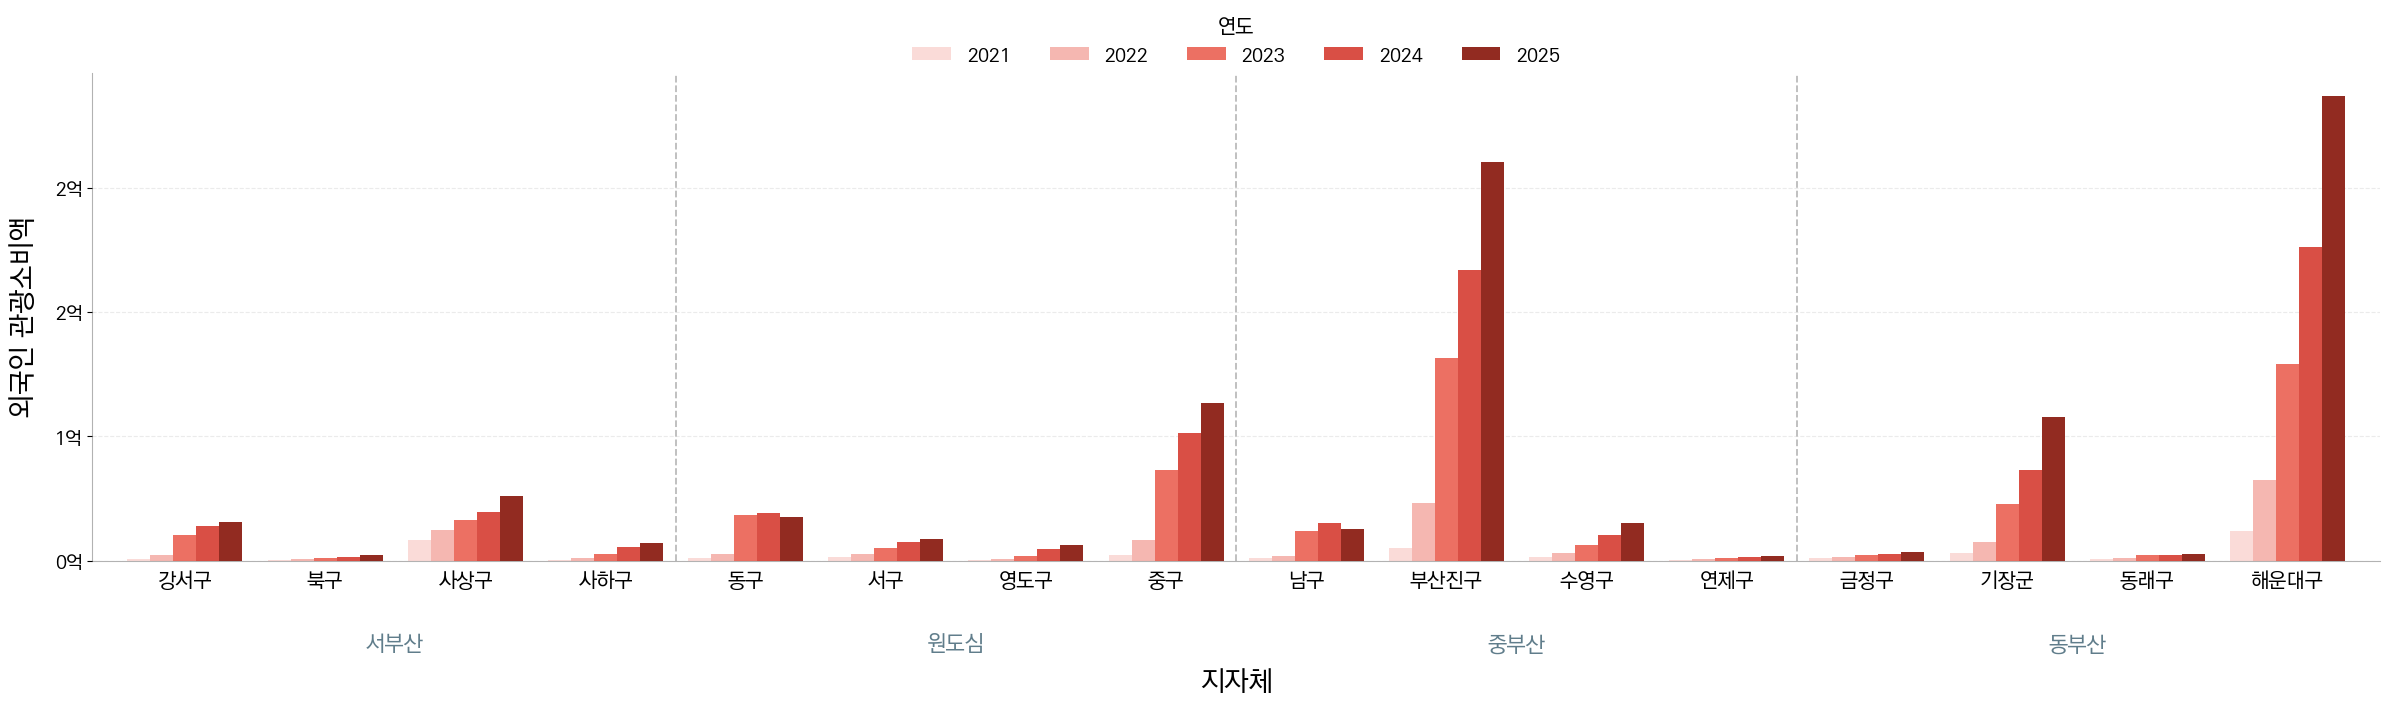

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator


# =========================================================
# 1. 데이터 복사
# =========================================================

df2 = df.copy()


# =========================================================
# 2. 부산 4개 권역 설정
# =========================================================

region_map = {
    # 원도심
    "중구": "원도심",
    "동구": "원도심",
    "서구": "원도심",
    "영도구": "원도심",

    # 중부산
    "남구": "중부산",
    "부산진구": "중부산",
    "수영구": "중부산",
    "연제구": "중부산",

    # 서부산
    "강서구": "서부산",
    "북구": "서부산",
    "사상구": "서부산",
    "사하구": "서부산",

    # 동부산
    "금정구": "동부산",
    "기장군": "동부산",
    "동래구": "동부산",
    "해운대구": "동부산",
}


# =========================================================
# 3. 권역 순서
# =========================================================

region_order = [
    "서부산",
    "원도심",
    "중부산",
    "동부산"
]


# =========================================================
# 4. 권역 추가
# =========================================================

df2["권역"] = df2["지자체"].map(region_map)

df2["권역"] = pd.Categorical(
    df2["권역"],
    categories=region_order,
    ordered=True
)


# =========================================================
# 5. 권역 → 지자체 가나다순 → 연도순
# =========================================================

plot_df = (
    df2
    .sort_values(
        ["권역", "지자체", "기준년월"],
        ascending=[True, True, True]
    )
    .copy()
)


# =========================================================
# 6. 외국인 관광소비액 피벗
# =========================================================

pivot_foreign = plot_df.pivot(
    index="지자체",
    columns="기준년월",
    values="외국인"
)


# =========================================================
# 7. 권역별 지자체 순서 생성
# =========================================================

gu_order = (
    plot_df[
        ["지자체", "권역"]
    ]
    .drop_duplicates()
    .sort_values(
        ["권역", "지자체"],
        ascending=[True, True]
    )
    ["지자체"]
    .tolist()
)


# =========================================================
# 8. 지자체 순서 + 연도 순서 적용
# =========================================================

pivot_foreign = (
    pivot_foreign
    .reindex(index=gu_order)
    .reindex(
        columns=[
            2021,
            2022,
            2023,
            2024,
            2025
        ]
    )
)


# =========================================================
# 9. 붉은 계열
# =========================================================

colors = [
    "#FADBD8",
    "#F5B7B1",
    "#EC7063",
    "#D94F45",
    "#922B21"
]


# =========================================================
# 10. 그래프
# =========================================================

fig, ax = plt.subplots(
    figsize=(24, 8)
)


pivot_foreign.plot(
    kind="bar",
    ax=ax,
    color=colors,
    width=0.82,
    edgecolor="none"
)


# =========================================================
# 11. 권역별 위치 계산
# =========================================================

region_positions = {}

for region in region_order:

    gu_in_region = (
        plot_df[
            plot_df["권역"] == region
        ]["지자체"]
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    positions = [
        gu_order.index(gu)
        for gu in gu_in_region
        if gu in gu_order
    ]

    if positions:

        region_positions[region] = {
            "start": min(positions),
            "end": max(positions)
        }


# =========================================================
# 12. 권역 사이 세로 점선
# =========================================================

for region in region_order:

    if region not in region_positions:
        continue

    start = region_positions[region]["start"]

    # 첫 번째 권역 앞에는 구분선 없음
    if start > 0:

        ax.axvline(
            x=start - 0.5,
            color="#9E9E9E",
            linewidth=1.3,
            linestyle="--",
            alpha=0.7,
            zorder=0
        )


# =========================================================
# 13. 아래쪽 권역명
# =========================================================

for region in region_order:

    if region not in region_positions:
        continue

    start = region_positions[region]["start"]
    end = region_positions[region]["end"]

    center = (start + end) / 2

    ax.text(
        center,
        -0.15,
        region,

        transform=ax.get_xaxis_transform(),

        ha="center",
        va="top",

        fontsize=16,
        fontweight="bold",

        color="#607D8B"
    )


# =========================================================
# 14. X축
# =========================================================

ax.set_xlabel(
    "지자체",
    fontsize=20,
    fontweight="bold",

    # 권역명과 겹치지 않도록 공간 확보
    labelpad=55
)


# =========================================================
# 15. Y축
# =========================================================

ax.set_ylabel(
    "외국인 관광소비액",
    fontsize=20,
    fontweight="bold",
    labelpad=12
)


# =========================================================
# 16. 틱 설정
# =========================================================

ax.tick_params(
    axis="x",
    labelsize=15,
    rotation=0,
    pad=8,
    length=0
)

ax.tick_params(
    axis="y",
    labelsize=14
)


# =========================================================
# 17. Y축 억 단위
# =========================================================

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, _: f"{x / 100_000_000:,.0f}억"
    )
)


# =========================================================
# 18. Y축 틱 개수
# =========================================================

ax.yaxis.set_major_locator(
    MaxNLocator(
        nbins=5
    )
)


# =========================================================
# 19. 범례
# =========================================================

ax.legend(
    title="연도",

    fontsize=14,
    title_fontsize=15,

    ncol=5,

    frameon=False,

    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),

    columnspacing=2
)


# =========================================================
# 20. 보조선
# =========================================================

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.25
)

ax.set_axisbelow(True)


# =========================================================
# 21. 테두리
# 기존 스타일 유지
# =========================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_alpha(0.3)
ax.spines["bottom"].set_alpha(0.3)


# =========================================================
# 22. 레이아웃
# 아래쪽 권역명 공간 확보
# =========================================================

plt.tight_layout(
    rect=[0, 0.08, 1, 1]
)


# =========================================================
# 23. 저장
# =========================================================

plt.savefig(
    "지자체별_연도별_외국인_관광소비액_4권역.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()